# Cluster-adapted BNT tutorial

A short, step-by-step walkthrough of the `bntcluster` framework: build a
**cluster-adapted BNT scheme** targeting a chosen lens redshift, apply it
to a **mock convergence map** containing one NFW cluster, and recover the
**nulled convergence map** $\tilde\kappa$ — the foreground-suppressed
weak-lensing observable centred on the target redshift.

The companion `paper_notebook.ipynb` reproduces the full paper analysis
(multiple clusters, four binning strategies, source-density sweep, starlet
W234 filtering).  This notebook is the **minimal pedagogical version**: one
cluster, one strategy, perfect source redshifts, and a plain **Gaussian
smoothing** in place of the wavelet filter.

## 1 · Setup

A single import gives the whole framework.  We pick a moderate target
lens redshift `Z_LENS = 0.5` and a small map geometry so the notebook runs
in seconds.  Raise `NPIX` for production-quality maps.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.ndimage import gaussian_filter

import bntcluster as bnt

# ── Target lens redshift ────────────────────────────────────────────────────
Z_LENS = 0.5                       # the BNT scheme will localise w_tilde here

# ── Map geometry / source sampling ──────────────────────────────────────────
FIELD_DEG          = 3.0           # square field, degrees
NPIX               = 256           # pixel side (raise for production)
N_GAL_PER_ARCMIN2  = 30.0          # Euclid-like source density

os.makedirs("./maps_tutorial", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False,
                     "xtick.direction": "in", "ytick.direction": "in",
                     "xtick.top": True, "ytick.right": True})

## 2 · Describe the survey

`SurveySetup` carries everything the BNT framework needs to know about the
survey: the source redshift distribution $n(z)$, source density, shape
noise, photo-$z$ model, field size, pixel resolution and cosmology.  Here
we use a **Euclid-like** $n(z)$ (`bnt.nz_euclid`) and a **Euclid-like**
photo-$z$ model (Gaussian scatter $\sigma_z=0.05(1+z)$ + $10\%$
catastrophic outliers).

The photo-$z$ model is part of the survey description: every scheme will
report both the **true-$z$** and the **photo-$z$** version of its
diagnostics.  For the rest of the tutorial we work in the perfect-redshift
case for the maps — but you can switch to photo-$z$ at any time by passing
photometric redshifts to the map generator.

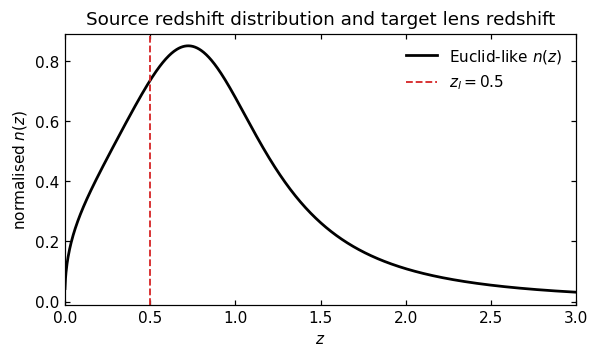

In [2]:
survey = bnt.SurveySetup(
    n_of_z                  = bnt.nz_euclid,
    n_gal_per_arcmin2       = N_GAL_PER_ARCMIN2,
    shape_noise             = 0.26,                # sigma_eps per shear component
    photoz_sigma            = 0.05,                # sigma_z = 0.05 * (1 + z)
    photoz_outlier_fraction = 0.10,                # 10% catastrophic outliers
    field_deg               = FIELD_DEG,
    npix                    = NPIX,
    cosmo_params            = bnt.DEFAULT_COSMO_PARAMS,
)

# `nuller` is the analytic BNT engine (kernels, BNT matrix) on the survey's
# z-grid; we just use it here to plot the Euclid n(z) we just selected.
nuller = survey.nuller

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(nuller.z, nuller.n_total, "k", lw=1.8, label=r"Euclid-like $n(z)$")
ax.axvline(Z_LENS, color="C3", ls="--", lw=1.2, label=fr"$z_l = {Z_LENS}$")
ax.set_xlim(0, 3); ax.set_xlabel(r"$z$"); ax.set_ylabel(r"normalised $n(z)$")
ax.set_title("Source redshift distribution and target lens redshift")
ax.legend(frameon=False); bnt.aa_style_ax(ax)
plt.show()

## 3 · The cost function and the cluster-adapted framework

The cluster-adapted BNT scheme uses **three** tomographic bins (two
foreground + one background) and chooses the bin edges by minimising a
single cost function

$$\mathcal{C}\;=\;\mathrm{base}\;\bigl[\,1+\lambda_{\rm pk}\,(z_{\rm peak}-z_l)^2 +\lambda_{\rm nl}\,\max(0,\,L-\varepsilon)^2\,\bigr],$$

where:

* `objective="max_R"` sets $\mathrm{base}=-\log R$, so minimising $\mathcal{C}$
  **maximises** the predicted BNT/unweighted detection-S/N ratio $R$
  (we use this objective, following the paper);
* `objective="min_alpha"` sets $\mathrm{base}=\alpha$, recovering the older
  shape-noise-minimising analysis;
* $\lambda_{\rm pk}$ penalises kernels that peak away from $z_l$;
* $\lambda_{\rm nl}$ penalises foreground leakage $L$ exceeding the
  tolerance $\varepsilon$.

`ClusterBNT.build_scheme(z_l, strategy)` optimises the bin edges and
returns a `ClusterBNTScheme` exposing the binning, the kernels, the BNT
weights, the nulled observable and the diagnostics ($\alpha$, $z_{\rm peak}$,
$L$, $R$).  Available strategies are `"equipopulated"`, `"1-free"`,
`"2-free"`, `"3-free"` (number of free bin edges).

In [3]:
cost = bnt.CostFunction(
    objective         = "max_R",     # minimise -log R
    peak_weight       = 200.0,       # lambda_pk -- kernel-peak fidelity
    leakage_weight    = 300.0,       # lambda_nl -- foreground-leakage penalty
    leakage_tolerance = 0.35,        # epsilon   -- tolerated leakage
)
cbnt = bnt.ClusterBNT(survey, cost)

# 3-free is the most flexible strategy: z_min, z_fg and z_bg are all optimised.
scheme = cbnt.build_scheme(Z_LENS, strategy="3-free")
scheme.summary()

Cluster-adapted BNT scheme — strategy: '3-free', z_lens = 0.5
  bin edges [z_min, z_fg, z_bg, z_max]: [0.001, 0.3932, 0.5636, 3.0]
  bin fractions (true z):  [0.1593, 0.122, 0.7187]
  true z :  alpha =  3.640   kernel peak = 0.532   leakage L = 34.6%   R_pred = 0.312
  photo-z:  alpha =  3.849   kernel peak = 0.559   leakage L = 34.2%   R_pred = 0.259


## 4 · Inspect the binning and the nulled kernel

The scheme exposes everything you need:

* `scheme.bin_edges`              — $[z_{\rm min}, z_{\rm fg}, z_{\rm bg}, z_{\rm max}]$;
* `scheme.bin_distributions_true` — the three per-bin source distributions $n_i(z)$;
* `scheme.kernels_true`           — the ordinary tomographic kernels $w_i(z)$;
* `scheme.bnt_weights_true`       — the three BNT coefficients $M_{2j}$ of the nulled row;
* `scheme.nulled_kernel_true`     — the BNT-weighted kernel $\tilde w(z)$.

The top panel shows the three bins over the $n(z)$; the bottom panel shows
the ordinary kernels $w_i(z)$ (dashed colours) and the nulled kernel
$\tilde w(z)$ (red): the latter peaks at $z_l$ and is $\sim 0$ for $z<z_l$,
i.e. it nulls the lensing response of any foreground structure.

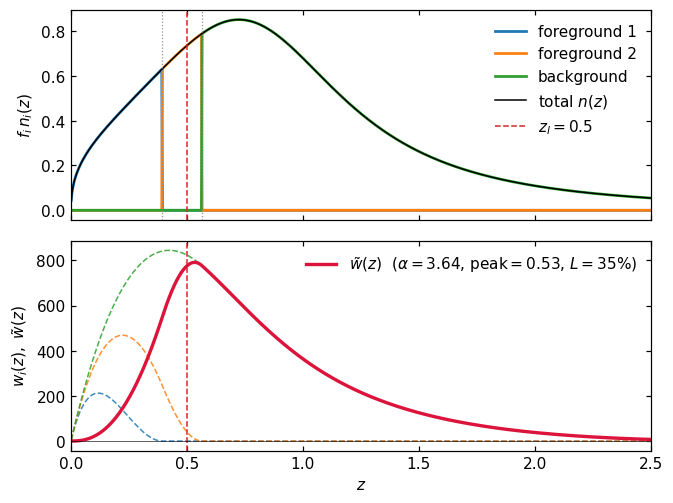

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(6.8, 5.2), sharex=True,
                         gridspec_kw={"hspace": 0.10})

# ── Top: tomographic source bins on top of n(z) ────────────────────────────
ax = axes[0]
bin_labels = ["foreground 1", "foreground 2", "background"]
for i, lbl in enumerate(bin_labels):
    ax.plot(nuller.z,
            scheme.bin_fractions_true[i] * scheme.bin_distributions_true[i],
            color=f"C{i}", lw=1.8, label=lbl)
ax.plot(nuller.z, nuller.n_total, "k", lw=1.0, label=r"total $n(z)$")
for e in scheme.bin_edges[1:-1]:
    ax.axvline(e, color="0.55", ls=":", lw=0.8)
ax.axvline(Z_LENS, color="C3", ls="--", lw=1.0, label=fr"$z_l = {Z_LENS}$")
ax.set_xlim(0, 2.5); ax.set_ylabel(r"$f_i\, n_i(z)$")
ax.legend(fontsize=8, frameon=False, loc="upper right")
bnt.aa_style_ax(ax)

# ── Bottom: ordinary kernels w_i (dashed) + the BNT-nulled kernel (red) ───
ax = axes[1]
for i in range(3):
    ax.plot(nuller.z, scheme.kernels_true[i], color=f"C{i}", lw=1.0, ls="--",
            alpha=0.85)
ax.plot(nuller.z, scheme.nulled_kernel_true, color="crimson", lw=2.2,
        label=fr"$\tilde w(z)$  ($\alpha={scheme.alpha_true:.2f}$, "
              fr"peak$={scheme.z_peak_true:.2f}$, $L={100*scheme.leakage_true:.0f}\%$)")
ax.axvline(Z_LENS, color="C3", ls="--", lw=1.0)
ax.axhline(0, color="k", lw=0.4)
ax.set_xlim(0, 2.5); ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_i(z),\ \tilde w(z)$")
ax.legend(fontsize=8, frameon=False, loc="upper right")
bnt.aa_style_ax(ax)
plt.show()

## 5 · Inject one NFW cluster and generate the convergence maps

We place a single $M_{200\rm c}= 10^{15}\,M_\odot$ NFW cluster at the
centre of the field, at the target redshift $z_l$, and generate **two** sets
of convergence maps from the same source catalogue and the same shape-noise
realisation:

* **(a) the unweighted reference** — a single source bin selecting all
  galaxies behind the lens ($z_s>z_l$, i.e. $z_{\rm min}=z_l$).  This is the
  map a standard cluster weak-lensing analysis would build: it has the
  highest signal-to-noise, but its broad lensing kernel responds to *all*
  foreground structure along the line of sight.
* **(b) the cluster-adapted BNT bins** — the three optimised bins of
  `scheme`, which §6 combines into the foreground-nulled map.

`ClusterBNT.build_map_generator` runs the NFW mock generator on the
requested bins (sharing one shape-noise RNG so each bin's noise realisation
is independent), and `bnt.stack_bin_maps(gen, noisy=...)` returns the
per-bin convergence maps.  Passing the **true** redshifts as both
catalogues selects sources by their true redshift — the perfect-redshift
case.

In [5]:
# One NFW lens at the centre of the field, at z = z_l.
cluster_ra, cluster_dec = FIELD_DEG / 2.0, FIELD_DEG / 2.0
lens_catalog = Table(dict(
    z    = [Z_LENS],
    RA   = [cluster_ra],
    Dec  = [cluster_dec],
    mass = [1e15],                                    # M_200c [M_sun]
))

# Mock source catalogue (true redshifts only; no photo-z scrambling).
rng = np.random.default_rng(42)
z_true, _ = survey.draw_source_catalog(rng)
print(f"sampled {len(z_true):,} source galaxies "
      f"({N_GAL_PER_ARCMIN2}/arcmin^2 over {FIELD_DEG}x{FIELD_DEG} deg^2)")

# ── (a) Unweighted reference: ONE source bin with z_s > z_l ─────────────────
# The map a standard cluster-lensing analysis would use: all sources behind
# the lens, no BNT.  Its kernel still responds to ALL foreground mass.
edges_unweighted = np.array([Z_LENS, cbnt.z_max_source])
gen_unw = cbnt.build_map_generator(
    bin_edges      = edges_unweighted,
    z_true_catalog = z_true,
    z_phot_catalog = z_true,
    lens_catalog   = lens_catalog,
    output_dir     = "./maps_tutorial_unweighted",
    noise_seed     = 17,
)
kappa_unw_noiseless = bnt.stack_bin_maps(gen_unw, noisy=False)[0]
kappa_unw_noisy     = bnt.stack_bin_maps(gen_unw, noisy=True)[0]

# ── (b) Cluster-adapted BNT: the THREE optimised bins ──────────────────────
gen = cbnt.build_map_generator(
    bin_edges      = scheme.bin_edges,
    z_true_catalog = z_true,
    z_phot_catalog = z_true,
    lens_catalog   = lens_catalog,
    output_dir     = "./maps_tutorial",
    noise_seed     = 17,
)
stack_noiseless = bnt.stack_bin_maps(gen, noisy=False)
stack_noisy     = bnt.stack_bin_maps(gen, noisy=True)

print("unweighted single-bin map shape:    ", kappa_unw_noiseless.shape)
print("cluster-adapted per-bin stack shape:", stack_noiseless.shape)

sampled 972,000 source galaxies (30.0/arcmin^2 over 3.0x3.0 deg^2)


Redshift cuts (noiseless):   0%|          | 0/1 [00:00<?, ?it/s]

Redshift cuts (noiseless):   0%|          | 0/3 [00:00<?, ?it/s]

unweighted single-bin map shape:     (256, 256)
cluster-adapted per-bin stack shape: (3, 256, 256)


## 6 · Apply the BNT weighting

The nulled convergence map is the BNT-weighted sum of the per-bin maps

$$\tilde\kappa(\boldsymbol\theta)\;=\;\sum_j M_{2j}\,\kappa_j(\boldsymbol\theta),$$

with the three weights $M_{2j}=$ `scheme.bnt_weights_true`.  The helper
`bnt.bnt_weighted_map(weights, stack)` does this in one line and returns a
map with the same `(NPIX, NPIX)` shape as a single per-bin map.

Because the three bins carry independent shape-noise realisations, the
weighted sum amplifies the per-pixel noise by
$\alpha=\sqrt{\sum_j M_{2j}^2/f_j}$ — the **shape-noise amplification**
reported by `scheme.alpha_true`.  This is the price the BNT transform pays
for nulling the foreground.

In [6]:
weights = scheme.bnt_weights_true
print(f"BNT weights M_2j:  {np.round(weights, 3)}")
print(f"shape-noise amplification alpha:  {scheme.alpha_true:.2f}")

kappa_BNT_noiseless = bnt.bnt_weighted_map(weights, stack_noiseless)
kappa_BNT_noisy     = bnt.bnt_weighted_map(weights, stack_noisy)

# A simple per-pixel S/N at the cluster centre (same noise realisation),
# for the unweighted reference and the BNT-nulled map, on the un-smoothed
# maps -- the BNT noise amplification shows up directly here.
i_c = j_c = NPIX // 2
def centre_snr(noiseless, noisy):
    return float(np.abs(noiseless[i_c, j_c]) / noisy.std())

print(f"\nraw (un-smoothed) per-pixel S/N at the cluster centre:")
print(f"  unweighted (z_s > z_l):  {centre_snr(kappa_unw_noiseless, kappa_unw_noisy):.2f}")
print(f"  BNT-nulled            :  {centre_snr(kappa_BNT_noiseless, kappa_BNT_noisy):.2f}")

BNT weights M_2j:  [ 0.191 -1.191  1.   ]
shape-noise amplification alpha:  3.64

raw (un-smoothed) per-pixel S/N at the cluster centre:
  unweighted (z_s > z_l):  4.64
  BNT-nulled            :  1.47


## 7 · Gaussian smoothing and final visualisation

Shape noise dominates the raw maps; a simple **Gaussian smoothing**
(`scipy.ndimage.gaussian_filter`, $\sigma=1.5\,\mathrm{arcmin}$) suppresses
high-frequency noise while preserving the cluster's $\sim$arcmin-scale
signal.

The figure compares the two observables column by column (noiseless /
noisy / smoothed), on a **shared colour scale per column** so the signal
loss and the noise rise from the top to the bottom row can be read
honestly:

* **top row** — the **unweighted** convergence map ($z_s>z_l$): the cluster
  is strong and clearly detected, but the underlying kernel is sensitive to
  all line-of-sight structure;
* **bottom row** — the **BNT-nulled** map $\tilde\kappa$: the foreground is
  nulled, but the shape noise is amplified by the factor $\alpha$ reported
  above, so the cluster (green circle, field centre) is far harder to
  recover.

This contrast is the central message of the paper: the BNT transform buys
foreground localisation at a steep noise cost.

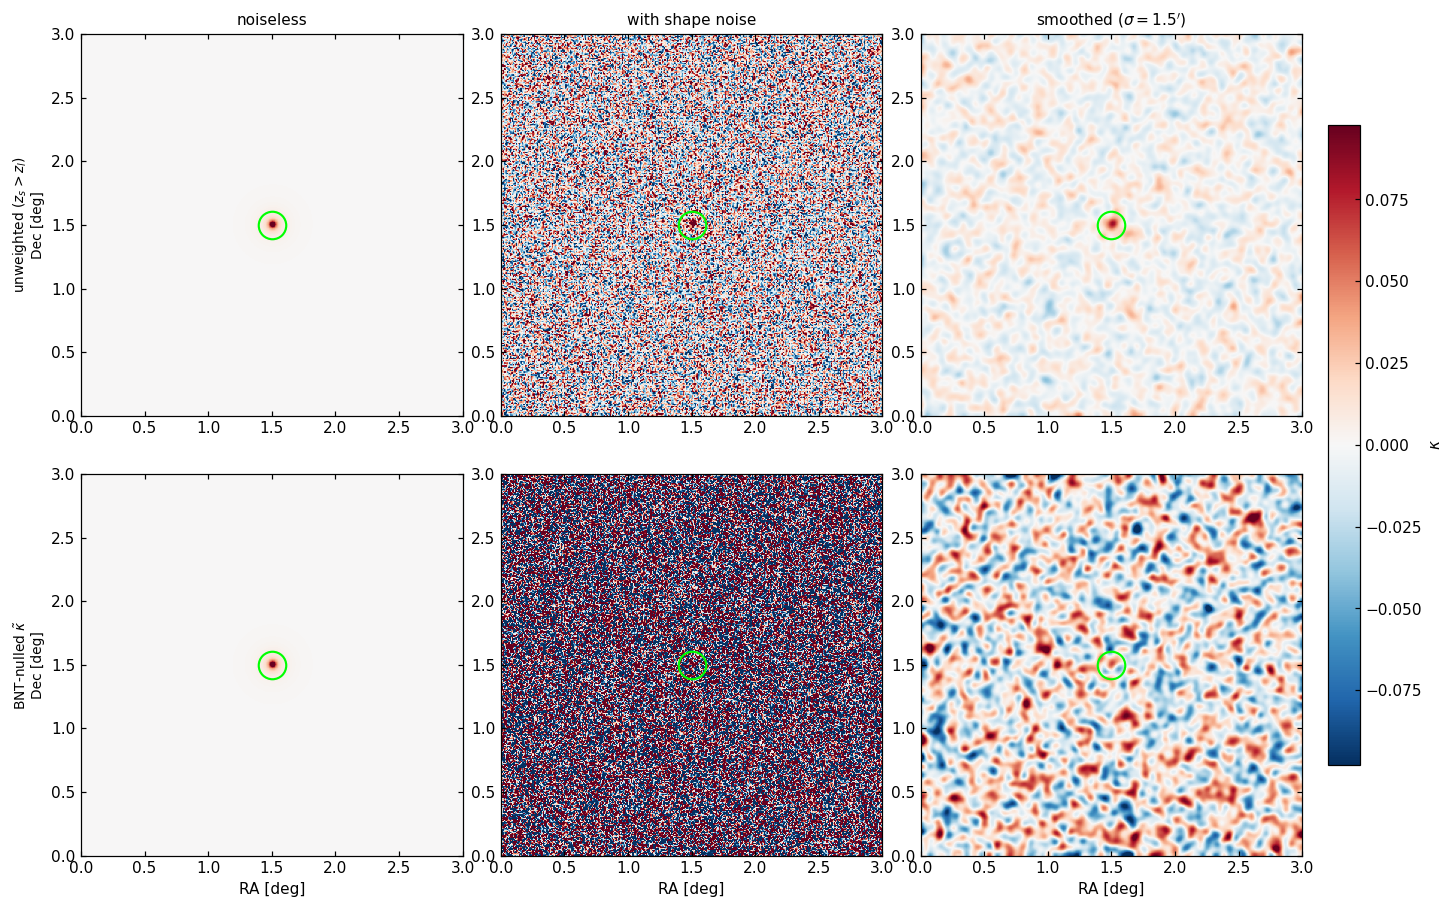

In [7]:
PIXEL_ARCMIN  = FIELD_DEG * 60.0 / NPIX
SMOOTH_ARCMIN = 1.5
sigma_pix     = SMOOTH_ARCMIN / PIXEL_ARCMIN

kappa_unw_smoothed = gaussian_filter(kappa_unw_noisy, sigma=sigma_pix)
kappa_BNT_smoothed = gaussian_filter(kappa_BNT_noisy, sigma=sigma_pix)

extent     = [0, FIELD_DEG, 0, FIELD_DEG]
col_titles = [
    "noiseless",
    "with shape noise",
    fr"smoothed ($\sigma={SMOOTH_ARCMIN}'$)"
]

rows = [
    (
        r"unweighted ($z_s>z_l$)",
        [kappa_unw_noiseless, kappa_unw_noisy, kappa_unw_smoothed]
    ),
    (
        r"BNT-nulled $\tilde\kappa$",
        [kappa_BNT_noiseless, kappa_BNT_noisy, kappa_BNT_smoothed]
    ),
]

# One shared symmetric colour scale for all subplots
all_maps = np.concatenate([
    img.ravel()
    for _, maps in rows
    for img in maps
])

vmax = float(np.percentile(np.abs(all_maps), 85)) or 1e-8

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 10),
    gridspec_kw={"wspace": 0.10, "hspace": 0.08}
)

for r, (row_label, maps) in enumerate(rows):
    for c, img in enumerate(maps):
        ax = axes[r, c]

        im = ax.imshow(
            img,
            origin="lower",
            extent=extent,
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax,
            aspect="equal"
        )

        ax.plot(
            cluster_ra,
            cluster_dec,
            "o",
            mfc="none",
            mec="lime",
            ms=18,
            mew=1.4
        )

        if r == 0:
            ax.set_title(col_titles[c], fontsize=10)
        else:
            ax.set_xlabel("RA [deg]")

        if c == 0:
            ax.set_ylabel(f"{row_label}\nDec [deg]", fontsize=9)

        bnt.aa_style_ax(ax)

# One fixed colour bar shared by all subplots
cbar = fig.colorbar(
    im,
    ax=axes,
    fraction=0.025,
    pad=0.02
)
cbar.set_label(r"$\kappa$", fontsize=10)

plt.show()